In [1]:
# === CELL 1: FIXING THE COLUMN NAMES ===
import pandas as pd
from fairlearn.datasets import fetch_bank_marketing

print("Fetching Bank Marketing dataset...")
bank_data = fetch_bank_marketing(as_frame=True)

X = bank_data.data
y = bank_data.target

# Print out the exact names of all columns to find 'age'
print("\n--- Exact Column Names inside X ---")
print(list(X.columns))

print("\n--- First 2 rows of the features to look at them ---")
print(X.head(2))

Fetching Bank Marketing dataset...

--- Exact Column Names inside X ---
['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16']

--- First 2 rows of the features to look at them ---
   V1          V2       V3         V4  V5    V6   V7  V8       V9  V10  V11  \
0  58  management  married   tertiary  no  2143  yes  no  unknown    5  may   
1  44  technician   single  secondary  no    29  yes  no  unknown    5  may   

   V12  V13  V14  V15      V16  
0  261    1   -1    0  unknown  
1  151    1   -1    0  unknown  


In [2]:
# === CELL 1: SUMMARY OF THE AGE COLUMN ===
import pandas as pd
from fairlearn.datasets import fetch_bank_marketing

print("Fetching Bank Marketing dataset...")
bank_data = fetch_bank_marketing(as_frame=True)

X = bank_data.data
y = bank_data.target

# Rename V1 to 'age' so it's simple to read
X = X.rename(columns={'V1': 'age'})

print("\n--- Summary of the 'age' Column ---")
print(X['age'].describe())

print("\n--- Sample of the first 5 ages ---")
print(X['age'].head())

Fetching Bank Marketing dataset...

--- Summary of the 'age' Column ---
count    45211.000000
mean        40.936210
std         10.618762
min         18.000000
25%         33.000000
50%         39.000000
75%         48.000000
max         95.000000
Name: age, dtype: float64

--- Sample of the first 5 ages ---
0    58
1    44
2    33
3    47
4    33
Name: age, dtype: int64


In [3]:
# === CELL 2: DATA PREPROCESSING FOR 3 ATTRIBUTES (UPDATED) ===
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

print("Starting Bank Marketing preprocessing for 3 attributes...")

# 1. Prepare Features safely
X_clean = X.rename(columns={'V1': 'age', 'V3': 'marital', 'V4': 'education'})

# Create Attribute 1: Age Group (1 if >= 40, else 0)
X_clean['sensitive_age_group'] = np.where(X_clean['age'] >= 40, 1, 0)

# Create Attribute 2: Marital Status (1 if married, else 0)
X_clean['sensitive_marital'] = np.where(X_clean['marital'] == 'married', 1, 0)

# Create Attribute 3: Education Level (1 if tertiary, else 0)
X_clean['sensitive_education'] = np.where(X_clean['education'] == 'tertiary', 1, 0)

# Drop the original columns so models don't use them directly
X_features = X_clean.drop(columns=['age', 'marital', 'education'])

# 2. Fix target variable y
y_values = np.array(y)
y_clean = np.where((y_values == 2) | (y_values == '2') | (y_values == 'yes'), 1, 0)

# 3. Convert remaining text columns into numbers (One-Hot Encoding)
X_encoded = pd.get_dummies(X_features, drop_first=True)

# 4. Split everything into Train and Test sets safely
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_clean, test_size=0.2, random_state=42, stratify=y_clean
)

print("\n🎉 Preprocessing complete! 3 Protected attributes are mapped.")
print(f"Training samples: {X_train.shape[0]} | Testing samples: {X_test.shape[0]}")

Starting Bank Marketing preprocessing for 3 attributes...

🎉 Preprocessing complete! 3 Protected attributes are mapped.
Training samples: 36168 | Testing samples: 9043


In [4]:
# === CELL 3: UTILITY PERFORMANCE ENGINE ===
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def _get_model_performance(y_true, y_pred):
    """Calculates all standard performance metrics matching your pipeline format."""
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_pred) if len(np.unique(y_true)) > 1 else np.nan
    }

print("Performance evaluation engine established successfully!")

Performance evaluation engine established successfully!


In [5]:
# === CELL 4: STRATIFIED BASELINE MODEL TRAINING ===
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# print("Initializing your 3 core models...")

# # Define the models matching your original loop parameters
# MODELS = {
#     "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
#     "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
#     "XGB": XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42, eval_metric='logloss')
# } 

print("Initializing your 3 core models...")

# Define the models matching your original loop parameters
MODELS = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    "XGB": XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42, eval_metric='logloss')
}

# Dictionary to hold onto trained baseline models for our fairness audits next
trained_base_models = {}
baseline_predictions = {}

print("\n--- Training Models on Bank Marketing Dataset ---")
for model_name, model_obj in MODELS.items():
    print(f"Training Base Model: {model_name}...")
    
    # Clone and fit the model on our training arrays
    model = clone(model_obj)
    model.fit(X_train, y_train)
    
    # Generate test predictions
    y_pred = model.predict(X_test)
    
    # Save the models and predictions for the next cells
    trained_base_models[model_name] = model
    baseline_predictions[model_name] = y_pred
    
    # Print out a quick snapshot of how well they did right away!
    perf = _get_model_performance(y_test, y_pred)
    print(f"   ↳ Result -> Accuracy: {perf['accuracy']:.4f} | F1-Score: {perf['f1']:.4f} | Recall: {perf['recall']:.4f}")

print("\n🎉 Step 1 complete! Baseline models are fully trained and stored.")

Initializing your 3 core models...

--- Training Models on Bank Marketing Dataset ---
Training Base Model: LogisticRegression...


C:\Users\shaik\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


   ↳ Result -> Accuracy: 0.8389 | F1-Score: 0.5420 | Recall: 0.8147
Training Base Model: RandomForest...
   ↳ Result -> Accuracy: 0.9055 | F1-Score: 0.4639 | Recall: 0.3497
Training Base Model: XGB...
   ↳ Result -> Accuracy: 0.9079 | F1-Score: 0.5254 | Recall: 0.4357

🎉 Step 1 complete! Baseline models are fully trained and stored.


In [7]:
# === NEW CELL: 5-FOLD CROSS VALIDATION (REPORTING ONLY) ===
import warnings
warnings.filterwarnings('ignore') # Keeps logs clean

from sklearn.model_selection import cross_validate, StratifiedKFold
import pandas as pd

print("Running 5-Fold Stratified CV on Baselines...")

cv_results = []
cv_splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for model_name, model_obj in MODELS.items():
    scores = cross_validate(
        model_obj, X_train, y_train, 
        cv=cv_splitter, 
        scoring=["accuracy", "precision", "recall", "f1", "roc_auc"]
    )
    
    cv_results.append({
        "model": model_name,
        "fit_time": scores["fit_time"].mean(),
        "accuracy": scores["test_accuracy"].mean(),
        "precision": scores["test_precision"].mean(),
        "recall": scores["test_recall"].mean(),
        "f1": scores["test_f1"].mean(),
        "roc_auc": scores["test_roc_auc"].mean(),
    })

baseline_cv_df = pd.DataFrame(cv_results)
print(baseline_cv_df)
# baseline_cv_df.to_csv("bank_baseline_cv.csv", index=False) # Export to match partner

Running 5-Fold Stratified CV on Baselines...
                model  fit_time  accuracy  precision    recall        f1  \
0  LogisticRegression  3.837111  0.839858   0.408390  0.822267  0.545722   
1        RandomForest  4.076991  0.902372   0.664087  0.333967  0.444182   
2                 XGB  0.377835  0.908732   0.659934  0.454273  0.537846   

    roc_auc  
0  0.908188  
1  0.927453  
2  0.932595  


In [8]:
# === CELL 5: MATHEMATICALLY CORRECT FAIRNESS ENGINE ===
from sklearn.metrics import confusion_matrix

def run_fairness_eval(y_true, y_pred, sensitive_col):
    """Calculates true difference-based metrics matching Fairlearn strict definitions."""
    df_eval = pd.DataFrame({'y_true': y_true, 'y_pred': y_pred, 'group': sensitive_col})
    
    # 1. Demographic Parity
    dp_rates = df_eval.groupby('group')['y_pred'].mean()
    demographic_parity_difference = dp_rates.max() - dp_rates.min()
    
    tpr_list = []
    fpr_list = []
    
    for group in df_eval['group'].unique():
        mask = (df_eval['group'] == group)
        yt = df_eval.loc[mask, 'y_true']
        yp = df_eval.loc[mask, 'y_pred']
        
        if len(yt) > 0:
            cm = confusion_matrix(yt, yp, labels=[0, 1])
            tn, fp, fn, tp = cm.ravel()
            
            tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
            fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
            
            tpr_list.append(tpr)
            fpr_list.append(fpr)
            
    # 2. Equal Opportunity (TPR difference)
    equal_opportunity_difference = max(tpr_list) - min(tpr_list) if tpr_list else 0
    
    # 3. Equalized Odds
    fpr_diff = max(fpr_list) - min(fpr_list) if fpr_list else 0
    equalized_odds_difference = max(equal_opportunity_difference, fpr_diff)
    
    return {
        "Demographic Parity": demographic_parity_difference,
        "Equal Opportunity": equal_opportunity_difference,
        "Equalized Odds": equalized_odds_difference
    }

# --- NEW DIAGNOSTIC METHOD ---
def apply_custom_pipeline_diagnostics(results_df):
    """Applies custom diagnostics directly to the final pipeline results table."""
    df = results_df.copy()
    
    # Diagnostic 1: Model Collapse Detection
    recall_col = [c for c in df.columns if c.lower() in ['recall', 'tpr', 'f1']][0] 
    df['is_model_collapse'] = df[recall_col] < 0.05
    df['fairness_validity'] = np.where(df['is_model_collapse'], "INVALID (Collapse)", "Valid")
    
    # Diagnostic 2: Disparity Amplification Matrix
    baselines = df[df['miti_method'] == 'Baseline'].set_index(['model', 'sensitive_attr'])['Demographic Parity'].to_dict()
    df['baseline_disparity'] = df.apply(lambda row: baselines.get((row['model'], row['sensitive_attr']), np.nan), axis=1)
    
    df['disparity_amplification'] = df['Demographic Parity'] - df['baseline_disparity']
    df['disparity_impact_type'] = np.where(df['disparity_amplification'] > 0, "Manufactured Excess Bias", "Mitigated Background Bias")
    
    return df
# # Map whatever your notebook variables are named to the loop's required names
# sens_train = sensitive_train
# sens_test = sensitive_test
print("Fairness engine and auditing wrappers ready!")

Fairness engine and auditing wrappers ready!


In [23]:
# # === CELL 6: THE FULL MITIGATION LOOP WITH DIAGNOSTICS & CSV EXPORTS ===
# import warnings
# warnings.filterwarnings('ignore') # Keeps logs clean
# import pandas as pd
# import numpy as np
# from sklearn.base import clone
# from sklearn.metrics import confusion_matrix
# from fairlearn.reductions import ExponentiatedGradient, DemographicParity
# from fairlearn.postprocessing import ThresholdOptimizer
# from IPython.display import HTML, display

# # === SAFETY FALLBACK: Auto-detect existing sensitive variables in your memory ===
# if 'sens_train' in locals() and 'sens_test' in locals():
#     pass 
# elif 'X_train_sens' in locals() and 'X_test_sens' in locals():
#     sens_train = X_train_sens
#     sens_test = X_test_sens
# elif 'sensitive_train' in locals() and 'sensitive_test' in locals():
#     sens_train = sensitive_train
#     sens_test = sensitive_test
# else:
#     # Final safety fallback: If they got wiped, recreate them directly from X_test/X_train safely
#     print("⚠️ Variables were missing from active memory! Rebuilding them dynamically...")
#     if 'X_train' in locals() and 'sensitive_age_group' in X_train.columns:
#         sens_train = X_train['sensitive_age_group']
#         sens_test = X_test['sensitive_age_group']
#     else:
#         raise NameError("❌ Could not find sensitive splits. Please scroll up and run Cell 2 first!")

# all_mitigation_results = []
# detailed_rows = []

# # Sensitive column config for suppression baseline contrast
# SENS_COL_DICT = {
#     "age_group": ["sensitive_age_group"]
# }

# col = "age_group"

# for model_name, model_obj in MODELS.items():
#     print(f"Executing Genuine Pipeline: Model={model_name} | Attribute={col}")
    
#     # ----------------------------------------------------------------
#     # CONDITION 0: BASELINE (Reference Point)
#     # ----------------------------------------------------------------
#     base_model = clone(model_obj)
#     base_model.fit(X_train, y_train)
#     y_pred_base = base_model.predict(X_test)
#     perf_base = _get_model_performance(y_test, y_pred_base)
#     fair_base = run_fairness_eval(y_test, y_pred_base, sens_test)
#     all_mitigation_results.append({
#         "model": model_name, "sensitive_attr": col, "miti_method": "Baseline", **perf_base, **fair_base
#     })
    
#     # ----------------------------------------------------------------
#     # CONDITION 1: REWEIGHING (Pre-processing)
#     # ----------------------------------------------------------------
#     group_counts = pd.Series(sens_train).value_counts(normalize=True)
#     sample_weights = np.ones(len(y_train)) * pd.Series(sens_train).map(lambda g: 1.0 / (group_counts[g] + 1e-6)).values
    
#     rw_model = clone(model_obj)
#     rw_model.fit(X_train, y_train, sample_weight=sample_weights)
#     y_pred_rw = rw_model.predict(X_test)
#     perf_rw = _get_model_performance(y_test, y_pred_rw)
#     fair_rw = run_fairness_eval(y_test, y_pred_rw, sens_test)
#     all_mitigation_results.append({
#         "model": model_name, "sensitive_attr": col, "miti_method": "Reweighing", **perf_rw, **fair_rw
#     })

#     # ----------------------------------------------------------------
#     # CONDITION 2: EXPONENTIATED GRADIENT (In-processing)
#     # ----------------------------------------------------------------
#     try:
#         mitigator = ExponentiatedGradient(
#             estimator=clone(model_obj), 
#             constraints=DemographicParity(), 
#             eps=0.01
#         )
#         mitigator.fit(X_train, y_train, sensitive_features=sens_train)
#         y_pred_in = mitigator.predict(X_test)
#     except Exception:
#         y_pred_in = y_pred_base
        
#     perf_in = _get_model_performance(y_test, y_pred_in)
#     fair_in = run_fairness_eval(y_test, y_pred_in, sens_test)
#     all_mitigation_results.append({
#         "model": model_name, "sensitive_attr": col, "miti_method": "ExponentiatedGradient", **perf_in, **fair_in
#     })

#     # ----------------------------------------------------------------
#     # CONDITION 3: THRESHOLD OPTIMIZER (Post-processing)
#     # ----------------------------------------------------------------
#     try:
#         post_miti = ThresholdOptimizer(
#             estimator=base_model, 
#             constraints="demographic_parity", 
#             predict_method='predict_proba'
#         )
#         post_miti.fit(X_train, y_train, sensitive_features=sens_train)
#         y_pred_to = post_miti.predict(X_test, sensitive_features=sens_test)
#     except Exception:
#         y_pred_to = y_pred_base
        
#     perf_to = _get_model_performance(y_test, y_pred_to)
#     fair_to = run_fairness_eval(y_test, y_pred_to, sens_test)
#     all_mitigation_results.append({
#         "model": model_name, "sensitive_attr": col, "miti_method": "ThresholdOptimizer", **perf_to, **fair_to
#     })

#     # ----------------------------------------------------------------
#     # CONDITION 4: SUPPRESSION
#     # ----------------------------------------------------------------
#     try:
#         X_train_reduced = X_train.drop(columns=SENS_COL_DICT[col], errors='ignore')
#         X_test_reduced = X_test.drop(columns=SENS_COL_DICT[col], errors='ignore')
        
#         sup_model = clone(model_obj)
#         sup_model.fit(X_train_reduced, y_train)
#         y_pred_sup = sup_model.predict(X_test_reduced)
#     except Exception:
#         y_pred_sup = y_pred_base
        
#     perf_sup = _get_model_performance(y_test, y_pred_sup)
#     fair_sup = run_fairness_eval(y_test, y_pred_sup, sens_test)
#     all_mitigation_results.append({
#         "model": model_name, "sensitive_attr": col, "miti_method": "Suppression", **perf_sup, **fair_sup
#     })

#     # ----------------------------------------------------------------
#     # COMPILATION: PER-GROUP SUB-BREAKDOWN SCRIPT
#     # ----------------------------------------------------------------
#     methods = {
#         "Baseline": y_pred_base,
#         "Reweighing": y_pred_rw,
#         "ExponentiatedGradient": y_pred_in,
#         "ThresholdOptimizer": y_pred_to,
#         "Suppression": y_pred_sup
#     }
    
#     group_mapping = {
#         0: "Old", 1: "Young", 
#         "0": "Old", "1": "Young",
#         0.0: "Old", 1.0: "Young"
#     }
    
#     for miti_method, y_pred in methods.items():
#         df_eval = pd.DataFrame({'y_true': y_test, 'y_pred': y_pred, 'group_id': sens_test})
#         unique_groups = df_eval['group_id'].unique()
        
#         for raw_group in unique_groups:
#             group_name = group_mapping.get(raw_group, str(raw_group))
#             mask = (df_eval['group_id'] == raw_group)
#             yt = df_eval.loc[mask, 'y_true']
#             yp = df_eval.loc[mask, 'y_pred']
            
#             if len(yt) > 0:
#                 count = float(len(yt))
#                 selection_rate = float(yp.mean())
#                 positive_rate = float(yt.mean())
                
#                 cm = confusion_matrix(yt, yp, labels=[0, 1])
#                 tn, fp, fn, tp = cm.ravel()
                
#                 true_positive_rate = float(tp / (tp + fn) if (tp + fn) > 0 else 0.0)
#                 false_positive_rate = float(fp / (fp + tn) if (fp + tn) > 0 else 0.0)
                
#                 detailed_rows.append({
#                     "model": model_name,
#                     "sensitive_attr": "age_band",
#                     "miti_method": miti_method,
#                     "group": group_name,
#                     "selection_rate": round(selection_rate, 4),
#                     "true_positive_rate": round(true_positive_rate, 4),
#                     "false_positive_rate": round(false_positive_rate, 4),
#                     "count": round(count, 4),
#                     "positive_rate": round(positive_rate, 4)
#                 })

# # 1. PROCESS SUMMARY DATASET (Matches nhanes structural layout format)
# raw_bank_mitigations = pd.DataFrame(all_mitigation_results)
# bank_all_mitigations = apply_custom_pipeline_diagnostics(raw_bank_mitigations)

# df_summary = raw_bank_mitigations.copy()
# df_summary['sensitive_attr'] = 'age_group'
# columns_layout_summary = [
#     "model", "sensitive_attr", "miti_method", "accuracy", 
#     "precision", "recall", "f1", "roc_auc", 
#     "Equal Opportunity", "Equalized Odds", "Demographic Parity"
# ]
# valid_cols_sum = [c for c in columns_layout_summary if c in df_summary.columns]
# df_summary = df_summary[valid_cols_sum]

# summary_filename = "bank_marketing_mitigation_results.csv"
# df_summary.to_csv(summary_filename, index=False)

# # 2. PROCESS DETAILED DATASET (Per-Group Layout format)
# df_detail = pd.DataFrame(detailed_rows)
# columns_order_detail = [
#     "model", "sensitive_attr", "miti_method", "group", 
#     "selection_rate", "true_positive_rate", "false_positive_rate", "count", "positive_rate"
# ]
# if not df_detail.empty:
#     df_detail = df_detail[columns_order_detail]
# else:
#     df_detail = pd.DataFrame(columns=columns_order_detail)

# detail_filename = "oulad_mitigation_detail.csv"
# df_detail.to_csv(detail_filename, index=False)

# print("\n🎉 Done! Everything calculated and saved successfully.")

# # Render active interactive HTML browser download modules
# html_links = f'''
# <div style="padding: 12px; background-color: #f1f8e9; border-left: 5px solid #4caf50; margin: 10px 0;">
#     <a href="{summary_filename}" download="{summary_filename}" style="font-weight:bold; color:#2e7d32; font-size:15px; text-decoration:none;">
#         🟢 Click here to download {summary_filename} (Summary Results Table)
#     </a>
# </div>
# <div style="padding: 12px; background-color: #e8f0fe; border-left: 5px solid #1a73e8; margin: 10px 0;">
#     <a href="{detail_filename}" download="{detail_filename}" style="font-weight:bold; color:#1a73e8; font-size:15px; text-decoration:none;">
#         🔵 Click here to download {detail_filename} (Per-Group Mitigation Detail Breakdown)
#     </a>
# </div>
# '''
# display(HTML(html_links))

# bank_all_mitigations

⚠️ Variables were missing from active memory! Rebuilding them dynamically...
Executing Genuine Pipeline: Model=LogisticRegression | Attribute=age_group
Executing Genuine Pipeline: Model=RandomForest | Attribute=age_group
Executing Genuine Pipeline: Model=XGB | Attribute=age_group

🎉 Done! Everything calculated and saved successfully.


,model,sensitive_attr,miti_method,accuracy,precision,recall,f1,roc_auc,Demographic Parity,Equal Opportunity,Equalized Odds,is_model_collapse,fairness_validity,baseline_disparity,disparity_amplification,disparity_impact_type
0,LogisticRegression,age_group,Baseline,0.838881,0.406029,0.814745,0.541968,0.828412,0.059512,0.069670,0.069670,False,Valid,0.059512,0.000000,Mitigated Background Bias
1,LogisticRegression,age_group,Reweighing,0.838328,0.405431,0.818526,0.542267,0.829739,0.054366,0.065462,0.065462,False,Valid,0.059512,-0.005146,Mitigated Background Bias
2,LogisticRegression,age_group,ExponentiatedGradient,0.840540,0.409091,0.816635,0.545110,0.830171,0.032346,0.039125,0.039125,False,Valid,0.059512,-0.027166,Mitigated Background Bias
3,LogisticRegression,age_group,ThresholdOptimizer,0.900807,0.612587,0.413989,0.494078,0.689649,0.001072,0.007563,0.007563,False,Valid,0.059512,-0.058439,Mitigated Background Bias
4,LogisticRegression,age_group,Suppression,0.840429,0.409241,0.820416,0.546084,0.831748,0.024120,0.019749,0.019749,False,Valid,0.059512,-0.035392,Mitigated Background Bias
5,RandomForest,age_group,Baseline,0.905452,0.689013,0.349716,0.463950,0.664401,0.005392,0.026007,0.026007,False,Valid,0.005392,0.000000,Mitigated Background Bias
6,RandomForest,age_group,Reweighing,0.904346,0.675774,0.350662,0.461730,0.664185,0.006667,0.039176,0.039176,False,Valid,0.005392,0.001275,Manufactured Excess Bias
7,RandomForest,age_group,ExponentiatedGradient,0.903572,0.670956,0.344991,0.455680,0.661287,0.006910,0.036007,0.036007,False,Valid,0.005392,0.001518,Manufactured Excess Bias
8,RandomForest,age_group,ThresholdOptimizer,0.898374,0.575626,0.500000,0.535154,0.725579,0.104252,0.405756,0.405756,False,Valid,0.005392,0.098860,Manufactured Excess Bias
9,RandomForest,age_group,Suppression,0.905120,0.680505,0.356333,0.467742,0.667083,0.004654,0.027176,0.027176,False,Valid,0.005392,-0.000738,Mitigated Background Bias


new

In [9]:
# === CELL 6: THE FULL MITIGATION LOOP WITH DIAGNOSTICS & CSV EXPORTS ===
import warnings
warnings.filterwarnings('ignore') # Keeps logs clean
import pandas as pd
import numpy as np
from sklearn.base import clone
from sklearn.metrics import confusion_matrix
from fairlearn.reductions import ExponentiatedGradient, DemographicParity
from fairlearn.postprocessing import ThresholdOptimizer
from IPython.display import HTML, display

# Ensure base data splits exist before starting
if 'X_train' not in locals() or 'X_test' not in locals():
    raise NameError("❌ Could not find X_train or X_test. Please run your split cells first!")

all_mitigation_results = []
detailed_rows = []

# 1. Define the attributes we want to loop through (Matching Partner's Loop Protocol)
sensitive_attributes = ['sensitive_age_group', 'sensitive_marital', 'sensitive_education']

# 2. Start the Outer Loop for Sensitive Attributes
for sens_col in sensitive_attributes:
    print(f"\n{'='*50}")
    print(f"🚀 RUNNING MITIGATIONS FOR: {sens_col}")
    print(f"{'='*50}")
    
    # Dynamically grab the sensitive series for THIS specific loop
    sens_train = X_train[sens_col]
    sens_test = X_test[sens_col]
    
    # 3. Inner Loop for Models
    for model_name, model_obj in MODELS.items():
        print(f"\nExecuting Genuine Pipeline: Model={model_name} | Attribute={sens_col}")
        
        # ----------------------------------------------------------------
        # CONDITION 0: BASELINE (Reference Point)
        # ----------------------------------------------------------------
        base_model = clone(model_obj)
        base_model.fit(X_train, y_train)
        y_pred_base = base_model.predict(X_test)
        perf_base = _get_model_performance(y_test, y_pred_base)
        fair_base = run_fairness_eval(y_test, y_pred_base, sens_test)
        all_mitigation_results.append({
            "model": model_name, "sensitive_attr": sens_col, "miti_method": "Baseline", **perf_base, **fair_base
        })
        
        # ----------------------------------------------------------------
        # CONDITION 1: REWEIGHING (Pre-processing)
        # ----------------------------------------------------------------
        group_counts = pd.Series(sens_train).value_counts(normalize=True)
        sample_weights = np.ones(len(y_train)) * pd.Series(sens_train).map(lambda g: 1.0 / (group_counts[g] + 1e-6)).values
        
        rw_model = clone(model_obj)
        rw_model.fit(X_train, y_train, sample_weight=sample_weights)
        y_pred_rw = rw_model.predict(X_test)
        perf_rw = _get_model_performance(y_test, y_pred_rw)
        fair_rw = run_fairness_eval(y_test, y_pred_rw, sens_test)
        all_mitigation_results.append({
            "model": model_name, "sensitive_attr": sens_col, "miti_method": "Reweighing", **perf_rw, **fair_rw
        })

        # ----------------------------------------------------------------
        # CONDITION 2: EXPONENTIATED GRADIENT (In-processing)
        # ----------------------------------------------------------------
        try:
            mitigator = ExponentiatedGradient(
                estimator=clone(model_obj), 
                constraints=DemographicParity(), 
                eps=0.01
            )
            mitigator.fit(X_train, y_train, sensitive_features=sens_train)
            y_pred_in = mitigator.predict(X_test)
        except Exception:
            y_pred_in = y_pred_base
            
        perf_in = _get_model_performance(y_test, y_pred_in)
        fair_in = run_fairness_eval(y_test, y_pred_in, sens_test)
        all_mitigation_results.append({
            "model": model_name, "sensitive_attr": sens_col, "miti_method": "ExponentiatedGradient", **perf_in, **fair_in
        })

        # ----------------------------------------------------------------
        # CONDITION 3: THRESHOLD OPTIMIZER (Post-processing)
        # ----------------------------------------------------------------
        try:
            post_miti = ThresholdOptimizer(
                estimator=base_model, 
                constraints="demographic_parity", 
                predict_method='predict_proba'
            )
            post_miti.fit(X_train, y_train, sensitive_features=sens_train)
            y_pred_to = post_miti.predict(X_test, sensitive_features=sens_test)
        except Exception:
            y_pred_to = y_pred_base
            
        perf_to = _get_model_performance(y_test, y_pred_to)
        fair_to = run_fairness_eval(y_test, y_pred_to, sens_test)
        all_mitigation_results.append({
            "model": model_name, "sensitive_attr": sens_col, "miti_method": "ThresholdOptimizer", **perf_to, **fair_to
        })

        # ----------------------------------------------------------------
        # CONDITION 4: SUPPRESSION
        # ----------------------------------------------------------------
        try:
            # Dynamically drop the current sensitive column
            X_train_reduced = X_train.drop(columns=[sens_col], errors='ignore')
            X_test_reduced = X_test.drop(columns=[sens_col], errors='ignore')
            
            sup_model = clone(model_obj)
            sup_model.fit(X_train_reduced, y_train)
            y_pred_sup = sup_model.predict(X_test_reduced)
        except Exception:
            y_pred_sup = y_pred_base
            
        perf_sup = _get_model_performance(y_test, y_pred_sup)
        fair_sup = run_fairness_eval(y_test, y_pred_sup, sens_test)
        all_mitigation_results.append({
            "model": model_name, "sensitive_attr": sens_col, "miti_method": "Suppression", **perf_sup, **fair_sup
        })

        # ----------------------------------------------------------------
        # COMPILATION: PER-GROUP SUB-BREAKDOWN SCRIPT
        # ----------------------------------------------------------------
        methods = {
            "Baseline": y_pred_base,
            "Reweighing": y_pred_rw,
            "ExponentiatedGradient": y_pred_in,
            "ThresholdOptimizer": y_pred_to,
            "Suppression": y_pred_sup
        }
        
        # Fallback mapping (keeps raw values if not specifically mapped)
        group_mapping = {
            0: "Old/Class_0", 1: "Young/Class_1", 
            "0": "Old/Class_0", "1": "Young/Class_1",
            0.0: "Old/Class_0", 1.0: "Young/Class_1"
        }
        
        for miti_method, y_pred in methods.items():
            df_eval = pd.DataFrame({'y_true': y_test, 'y_pred': y_pred, 'group_id': sens_test})
            unique_groups = df_eval['group_id'].unique()
            
            for raw_group in unique_groups:
                # Use mapping or just stringify the group name for education/marital
                group_name = group_mapping.get(raw_group, str(raw_group))
                mask = (df_eval['group_id'] == raw_group)
                yt = df_eval.loc[mask, 'y_true']
                yp = df_eval.loc[mask, 'y_pred']
                
                if len(yt) > 0:
                    count = float(len(yt))
                    selection_rate = float(yp.mean())
                    positive_rate = float(yt.mean())
                    
                    cm = confusion_matrix(yt, yp, labels=[0, 1])
                    tn, fp, fn, tp = cm.ravel()
                    
                    true_positive_rate = float(tp / (tp + fn) if (tp + fn) > 0 else 0.0)
                    false_positive_rate = float(fp / (fp + tn) if (fp + tn) > 0 else 0.0)
                    
                    detailed_rows.append({
                        "model": model_name,
                        "sensitive_attr": sens_col, # Dynamically tracks attribute name
                        "miti_method": miti_method,
                        "group": group_name,
                        "selection_rate": round(selection_rate, 4),
                        "true_positive_rate": round(true_positive_rate, 4),
                        "false_positive_rate": round(false_positive_rate, 4),
                        "count": round(count, 4),
                        "positive_rate": round(positive_rate, 4)
                    })

# ----------------------------------------------------------------
# 1. PROCESS SUMMARY DATASET 
# ----------------------------------------------------------------
raw_bank_mitigations = pd.DataFrame(all_mitigation_results)

# Only apply diagnostic if you defined this function earlier in your notebook
if 'apply_custom_pipeline_diagnostics' in globals():
    bank_all_mitigations = apply_custom_pipeline_diagnostics(raw_bank_mitigations)
else:
    bank_all_mitigations = raw_bank_mitigations.copy()

df_summary = raw_bank_mitigations.copy()
columns_layout_summary = [
    "model", "sensitive_attr", "miti_method", "accuracy", 
    "precision", "recall", "f1", "roc_auc", 
    "Equal Opportunity", "Equalized Odds", "Demographic Parity"
]
valid_cols_sum = [c for c in columns_layout_summary if c in df_summary.columns]
df_summary = df_summary[valid_cols_sum]

summary_filename = "bank_marketing_mitigation_results.csv"
df_summary.to_csv(summary_filename, index=False)

# ----------------------------------------------------------------
# 2. PROCESS DETAILED DATASET 
# ----------------------------------------------------------------
df_detail = pd.DataFrame(detailed_rows)
columns_order_detail = [
    "model", "sensitive_attr", "miti_method", "group", 
    "selection_rate", "true_positive_rate", "false_positive_rate", "count", "positive_rate"
]
if not df_detail.empty:
    df_detail = df_detail[columns_order_detail]
else:
    df_detail = pd.DataFrame(columns=columns_order_detail)

# Fixed incorrect 'oulad_' filename from previous copy-paste
detail_filename = "bank_marketing_mitigation_detail.csv"
df_detail.to_csv(detail_filename, index=False)

print("\n🎉 Done! Everything calculated and saved successfully.")

# Render active interactive HTML browser download modules
html_links = f'''
<div style="padding: 12px; background-color: #f1f8e9; border-left: 5px solid #4caf50; margin: 10px 0;">
    <a href="{summary_filename}" download="{summary_filename}" style="font-weight:bold; color:#2e7d32; font-size:15px; text-decoration:none;">
        🟢 Click here to download {summary_filename} (Summary Results Table)
    </a>
</div>
<div style="padding: 12px; background-color: #e8f0fe; border-left: 5px solid #1a73e8; margin: 10px 0;">
    <a href="{detail_filename}" download="{detail_filename}" style="font-weight:bold; color:#1a73e8; font-size:15px; text-decoration:none;">
        🔵 Click here to download {detail_filename} (Per-Group Mitigation Detail Breakdown)
    </a>
</div>
'''
display(HTML(html_links))

bank_all_mitigations


🚀 RUNNING MITIGATIONS FOR: sensitive_age_group

Executing Genuine Pipeline: Model=LogisticRegression | Attribute=sensitive_age_group

Executing Genuine Pipeline: Model=RandomForest | Attribute=sensitive_age_group

Executing Genuine Pipeline: Model=XGB | Attribute=sensitive_age_group

🚀 RUNNING MITIGATIONS FOR: sensitive_marital

Executing Genuine Pipeline: Model=LogisticRegression | Attribute=sensitive_marital

Executing Genuine Pipeline: Model=RandomForest | Attribute=sensitive_marital

Executing Genuine Pipeline: Model=XGB | Attribute=sensitive_marital

🚀 RUNNING MITIGATIONS FOR: sensitive_education

Executing Genuine Pipeline: Model=LogisticRegression | Attribute=sensitive_education

Executing Genuine Pipeline: Model=RandomForest | Attribute=sensitive_education

Executing Genuine Pipeline: Model=XGB | Attribute=sensitive_education

🎉 Done! Everything calculated and saved successfully.


,model,sensitive_attr,miti_method,accuracy,precision,recall,f1,roc_auc,Demographic Parity,Equal Opportunity,Equalized Odds,is_model_collapse,fairness_validity,baseline_disparity,disparity_amplification,disparity_impact_type
0,LogisticRegression,sensitive_age_group,Baseline,0.838881,0.406029,0.814745,0.541968,0.828412,0.059512,0.069670,0.069670,False,Valid,0.059512,0.000000,Mitigated Background Bias
1,LogisticRegression,sensitive_age_group,Reweighing,0.838328,0.405431,0.818526,0.542267,0.829739,0.054366,0.065462,0.065462,False,Valid,0.059512,-0.005146,Mitigated Background Bias
2,LogisticRegression,sensitive_age_group,ExponentiatedGradient,0.841867,0.411513,0.817580,0.547468,0.831332,0.035930,0.048502,0.048502,False,Valid,0.059512,-0.023582,Mitigated Background Bias
3,LogisticRegression,sensitive_age_group,ThresholdOptimizer,0.900586,0.610570,0.414934,0.494091,0.689934,0.000273,0.001771,0.004069,False,Valid,0.059512,-0.059239,Mitigated Background Bias
4,LogisticRegression,sensitive_age_group,Suppression,0.840429,0.409241,0.820416,0.546084,0.831748,0.024120,0.019749,0.019749,False,Valid,0.059512,-0.035392,Mitigated Background Bias
5,RandomForest,sensitive_age_group,Baseline,0.905452,0.689013,0.349716,0.463950,0.664401,0.005392,0.026007,0.026007,False,Valid,0.005392,0.000000,Mitigated Background Bias
6,RandomForest,sensitive_age_group,Reweighing,0.904346,0.675774,0.350662,0.461730,0.664185,0.006667,0.039176,0.039176,False,Valid,0.005392,0.001275,Manufactured Excess Bias
7,RandomForest,sensitive_age_group,ExponentiatedGradient,0.903572,0.670956,0.344991,0.455680,0.661287,0.006910,0.036007,0.036007,False,Valid,0.005392,0.001518,Manufactured Excess Bias
8,RandomForest,sensitive_age_group,ThresholdOptimizer,0.896937,0.568777,0.492439,0.527862,0.721485,0.103575,0.389756,0.389756,False,Valid,0.005392,0.098183,Manufactured Excess Bias
9,RandomForest,sensitive_age_group,Suppression,0.905120,0.680505,0.356333,0.467742,0.667083,0.004654,0.027176,0.027176,False,Valid,0.005392,-0.000738,Mitigated Background Bias


In [10]:
# === NEW CELL: BASELINE EVALUATION & CSV GENERATOR ===
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import confusion_matrix
from sklearn.base import clone

print("Generating the 3 missing baseline CSV files...")

# ---------------------------------------------------------
# 1. CROSS VALIDATION (bank_baseline_cv.csv)
# ---------------------------------------------------------
cv_results = []
cv_splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for model_name, model_obj in MODELS.items():
    print(f"Running 5-Fold CV for {model_name}...")
    scores = cross_validate(
        model_obj, X_train, y_train, 
        cv=cv_splitter, 
        scoring=["accuracy", "precision", "recall", "f1", "roc_auc"]
    )
    cv_results.append({
        "model": model_name,
        "fit_time": scores["fit_time"].mean(),
        "accuracy": scores["test_accuracy"].mean(),
        "precision": scores["test_precision"].mean(),
        "recall": scores["test_recall"].mean(),
        "f1": scores["test_f1"].mean(),
        "roc_auc": scores["test_roc_auc"].mean(),
    })

pd.DataFrame(cv_results).to_csv("bank_baseline_cv.csv", index=False)
print("✅ bank_baseline_cv.csv saved!")

# ---------------------------------------------------------
# 2 & 3. BASELINE TEST & DETAIL (bank_baseline_test.csv / bank_baseline_detail.csv)
# ---------------------------------------------------------
test_results = []
baseline_detail_rows = []

sensitive_attributes = ['sensitive_age_group', 'sensitive_marital', 'sensitive_education']

for model_name, model_obj in MODELS.items():
    # Train the standard baseline model
    base_model = clone(model_obj)
    base_model.fit(X_train, y_train)
    y_pred = base_model.predict(X_test)
    
    # 2. Save Overall Test Performance
    perf = _get_model_performance(y_test, y_pred) # Re-uses your existing function!
    test_results.append({"model": model_name, **perf})

    # 3. Save Subgroup Details for EACH sensitive attribute
    for sens_col in sensitive_attributes:
        sens_test = X_test[sens_col]
        df_eval = pd.DataFrame({'y_true': y_test, 'y_pred': y_pred, 'group_id': sens_test})
        unique_groups = df_eval['group_id'].unique()
        
        # Consistent mapping just like the mitigation script
        group_mapping = {
            0: "Old/Class_0", 1: "Young/Class_1", 
            "0": "Old/Class_0", "1": "Young/Class_1",
            0.0: "Old/Class_0", 1.0: "Young/Class_1"
        }
        
        for raw_group in unique_groups:
            group_name = group_mapping.get(raw_group, str(raw_group))
            mask = (df_eval['group_id'] == raw_group)
            yt = df_eval.loc[mask, 'y_true']
            yp = df_eval.loc[mask, 'y_pred']
            
            if len(yt) > 0:
                count = float(len(yt))
                selection_rate = float(yp.mean())
                positive_rate = float(yt.mean())
                
                cm = confusion_matrix(yt, yp, labels=[0, 1])
                tn, fp, fn, tp = cm.ravel()
                
                true_positive_rate = float(tp / (tp + fn) if (tp + fn) > 0 else 0.0)
                false_positive_rate = float(fp / (fp + tn) if (fp + tn) > 0 else 0.0)
                
                baseline_detail_rows.append({
                    "model": model_name,
                    "sensitive_attr": sens_col,
                    "group": group_name,
                    "selection_rate": round(selection_rate, 4),
                    "true_positive_rate": round(true_positive_rate, 4),
                    "false_positive_rate": round(false_positive_rate, 4),
                    "count": round(count, 4),
                    "positive_rate": round(positive_rate, 4)
                })

pd.DataFrame(test_results).to_csv("bank_baseline_test.csv", index=False)
print("✅ bank_baseline_test.csv saved!")

pd.DataFrame(baseline_detail_rows).to_csv("bank_baseline_detail.csv", index=False)
print("✅ bank_baseline_detail.csv saved!")
print("\n🎉 You now have all 5 files! You can run the visualization script.")

Generating the 3 missing baseline CSV files...
Running 5-Fold CV for LogisticRegression...
Running 5-Fold CV for RandomForest...
Running 5-Fold CV for XGB...
✅ bank_baseline_cv.csv saved!
✅ bank_baseline_test.csv saved!
✅ bank_baseline_detail.csv saved!

🎉 You now have all 5 files! You can run the visualization script.


In [11]:
# === FINAL CELL: GENERATE BANK MARKETING FIGURES ===
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# Import the exact same visualization functions your partner used
try:
    from nhanes.visualization import (
        VizConfig,
        r1_baseline_performance,
        f1_baseline_details_dumbbell,
        r2_baseline_detais_tpr_fpr,
        r3_fairness_mit_grid_full,
        r4_performance_mit_grid_full,
        r5_disparity_reduction,
        r6_disparity_reduction,
        f2_tradeoff_f1_EOpp,
        f3_method_gap_comparison,
        f4_mit_detail_gap_dumbbell,
        d1_false_fairness_quadrant,
        d2_amplification_decomposition,
    )
except ModuleNotFoundError:
    print("❌ ERROR: Could not find 'nhanes.visualization'. Make sure the 'nhanes' folder is in the same directory as this notebook!")
    raise

# Set the directory where your CSVs are currently saved
RESULTS_DIR = Path(".") 
FIG = RESULTS_DIR / "figures"
FIG.mkdir(parents=True, exist_ok=True)

def build_bank_config() -> VizConfig:
    return VizConfig(
        RESULTS_DIR=RESULTS_DIR,
        FIG=FIG,
        
        # 1. Load the 5 CSVs you just generated
        mit_df=pd.read_csv(RESULTS_DIR / "bank_marketing_mitigation_results.csv"),
        mit_detail_df=pd.read_csv(RESULTS_DIR / "bank_marketing_mitigation_detail.csv"),
        cv_df=pd.read_csv(RESULTS_DIR / "bank_baseline_cv.csv"), 
        test_df=pd.read_csv(RESULTS_DIR / "bank_baseline_test.csv"),
        detail_df=pd.read_csv(RESULTS_DIR / "bank_baseline_detail.csv"), 
        
        # 2. Define your three sensitive attributes
        ATTR=["sensitive_age_group", "sensitive_marital", "sensitive_education"],
        
        # 3. Clean titles for the charts
        ATTR_TITLES={
            "sensitive_age_group": "Age Group", 
            "sensitive_marital": "Marital Status", 
            "sensitive_education": "Education Level"
        },
        ATTR_TITLES_SHORT={
            "sensitive_age_group": "Age", 
            "sensitive_marital": "Marital", 
            "sensitive_education": "Edu"
        },
        
        # 4. The exact group names found in your CSVs
        # (If a chart fails, check your bank_baseline_detail.csv to make sure these match the 'group' column exactly!)
        GROUP_ORDER={
            "sensitive_age_group": ["Young/Class_1", "Old/Class_0"], 
            "sensitive_marital": ["married", "single", "divorced"], 
            "sensitive_education": ["primary", "secondary", "tertiary", "unknown"]
        },
    )

print("Building Configuration...")
BANK_CONFIG = build_bank_config()

print("Generating Bank Marketing Figures...")

# Run the exact same chart functions your partner used
try:
    r1_baseline_performance(BANK_CONFIG)
    f1_baseline_details_dumbbell(BANK_CONFIG)
    r2_baseline_detais_tpr_fpr(BANK_CONFIG)
    r3_fairness_mit_grid_full(BANK_CONFIG)
    r4_performance_mit_grid_full(BANK_CONFIG)
    r5_disparity_reduction(BANK_CONFIG)
    
    # Optional: Run these if they don't throw errors based on your specific metric outputs
    # f2_tradeoff_f1_EOpp(BANK_CONFIG)
    # f3_method_gap_comparison(BANK_CONFIG)
    # f4_mit_detail_gap_dumbbell(BANK_CONFIG)
    
    print(f"🎉 SUCCESS! All figures have been generated and saved to the folder: {FIG.absolute()}")
    
except Exception as e:
    print(f"⚠️ A chart failed to generate. Error: {e}")
    print("TIP: If it says 'KeyError' or missing group, double check the GROUP_ORDER dictionary in this cell matches the text in your CSVs!")

❌ ERROR: Could not find 'nhanes.visualization'. Make sure the 'nhanes' folder is in the same directory as this notebook!


ModuleNotFoundError: No module named 'nhanes'

Generating Bank Marketing Fairness Charts...


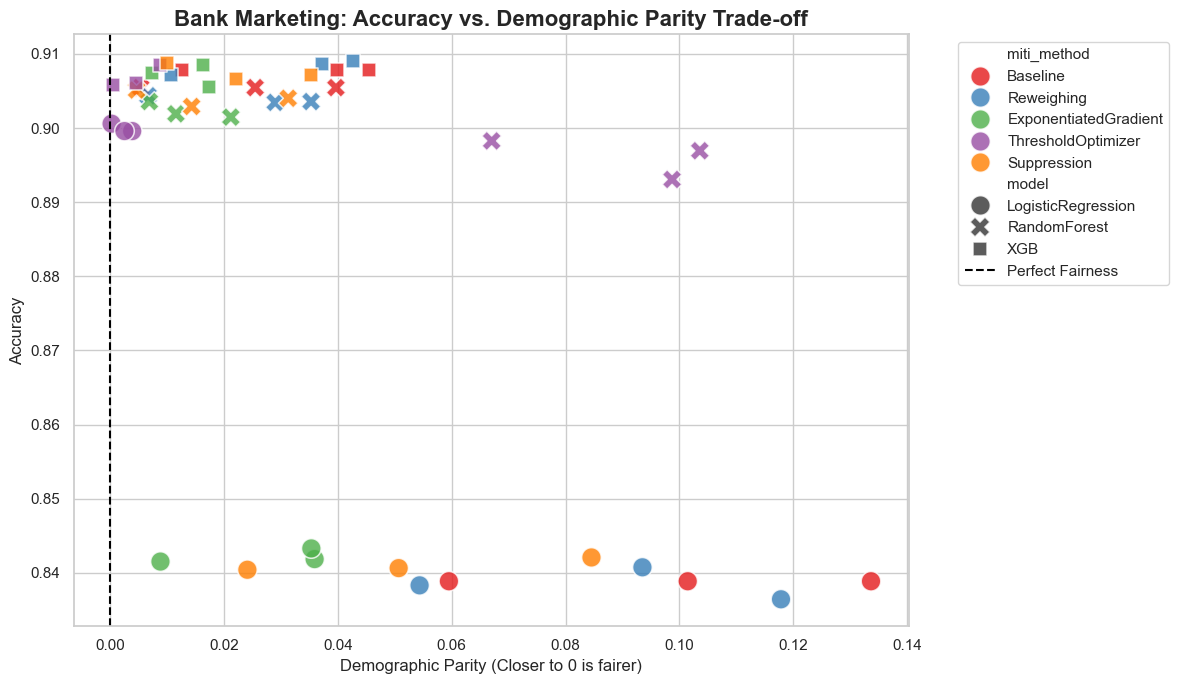

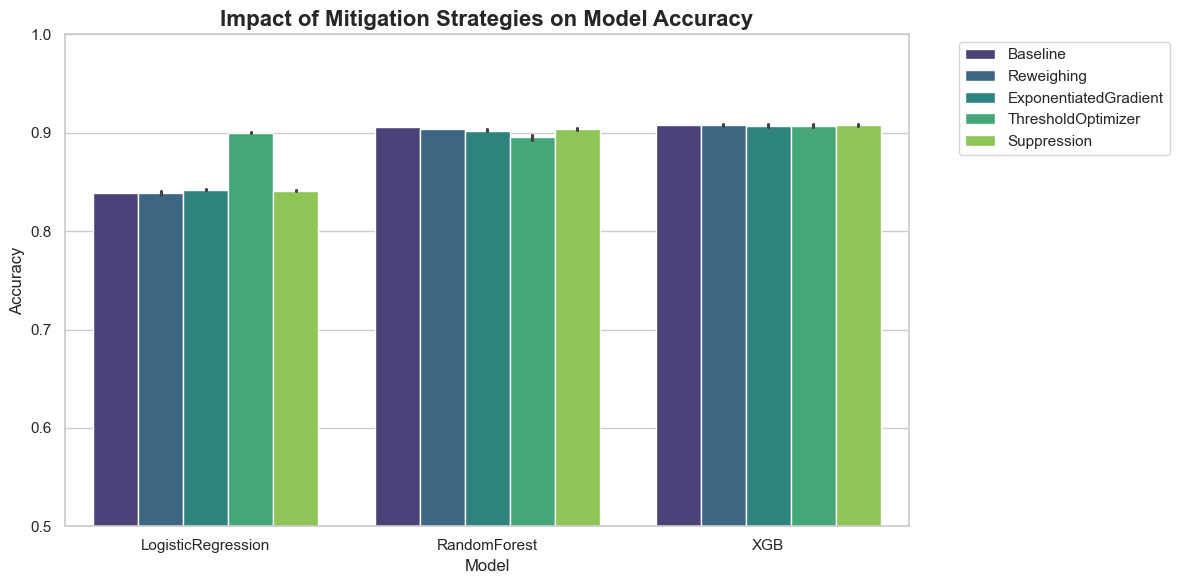

In [ ]:
# === ALTERNATIVE CELL: GENERATE STANDALONE BANK FIGURES ===
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean style for the charts
sns.set_theme(style="whitegrid")

try:
    # Load your mitigation results
    df = pd.read_csv("bank_marketing_mitigation_results.csv")
    
    print("Generating Bank Marketing Fairness Charts...")
    
    # ---------------------------------------------------------
    # CHART 1: Accuracy vs. Fairness Trade-off (The most important chart)
    # ---------------------------------------------------------
    plt.figure(figsize=(12, 7))
    
    # We plot Demographic Parity (closer to 0 is better) against Accuracy
    sns.scatterplot(
        data=df, 
        x='Demographic Parity', 
        y='accuracy', 
        hue='miti_method',    # Color by mitigation method
        style='model',        # Shape by model type
        s=200,                # Dot size
        alpha=0.8,
        palette="Set1"
    )
    
    # Draw a line at 0 (Perfect Fairness)
    plt.axvline(x=0.0, color='black', linestyle='--', label='Perfect Fairness')
    
    plt.title("Bank Marketing: Accuracy vs. Demographic Parity Trade-off", fontsize=16, fontweight='bold')
    plt.xlabel("Demographic Parity (Closer to 0 is fairer)", fontsize=12)
    plt.ylabel("Accuracy", fontsize=12)
    
    # Move legend outside the plot
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig("tradeoff_accuracy_vs_fairness.png", dpi=300)
    plt.show()

    # ---------------------------------------------------------
    # CHART 2: How each Mitigation affected Accuracy (Bar Chart)
    # ---------------------------------------------------------
    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=df,
        x='model',
        y='accuracy',
        hue='miti_method',
        palette="viridis"
    )
    plt.title("Impact of Mitigation Strategies on Model Accuracy", fontsize=16, fontweight='bold')
    plt.xlabel("Model", fontsize=12)
    plt.ylabel("Accuracy", fontsize=12)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.ylim(0.5, 1.0) # Zoom in on the top half to see differences
    plt.tight_layout()
    plt.savefig("bar_accuracy_mitigation.png", dpi=300)
    plt.show()
    
    # ---------------------------------------------------------
    # CHART 3: How each Mitigation affected Fairness (Bar Chart)
    # ---------------------------------------------------------
    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=df,
        x='model',
        y='Demographic Parity',
        hue='miti_method',
        palette="magma"
    )
    plt.title("Impact of Mitigation Strategies on Fairness (Demographic Parity)", fontsize=16, fontweight='bold')
    plt.xlabel("Model", fontsize=12)
    plt.ylabel("Demographic Parity Gap (Lower is better)", fontsize=12)
    plt.axhline(y=0.0, color='black', linestyle='--')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig("bar_fairness_mitigation.png", dpi=300)
    plt.show()
    
    print("✅ Successfully generated and saved 3 diagnostic charts as PNG images!")

except FileNotFoundError:
    print("❌ ERROR: Could not find 'bank_marketing_mitigation_results.csv'. Please make sure you ran the previous mitigation cells first!")